In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import CategoricalCrossentropy
import joblib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


In [ ]:
# ==================== IMPORTS ====================
import pandas as pd 
import kagglehub as kh
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

# ==================== DOWNLOAD & LOAD DATA ====================
# Download dataset from KaggleHub
path = kh.dataset_download("shayanfazeli/heartbeat")

def load_data(path):
    mitbih_train = pd.read_csv(os.path.join(path, "mitbih_train.csv"), header=None)
    mitbih_test = pd.read_csv(os.path.join(path, "mitbih_test.csv"), header=None)
    ptbdb_normal = pd.read_csv(os.path.join(path, "ptbdb_normal.csv"), header=None)
    ptbdb_abnormal = pd.read_csv(os.path.join(path, "ptbdb_abnormal.csv"), header=None)
    return mitbih_train, mitbih_test, ptbdb_normal, ptbdb_abnormal

mitbih_train, mitbih_test, ptbdb_normal, ptbdb_abnormal = load_data(path)

# ==================== ASSIGN LABELS FOR PTBDB ====================
def replace_label_column(data, label):
    data.iloc[:, -1] = label
    return data

ptbdb_normal = replace_label_column(ptbdb_normal, 6)  # normal
ptbdb_abnormal = replace_label_column(ptbdb_abnormal, 7)  # abnormal

ptbdb_all = pd.concat([ptbdb_normal, ptbdb_abnormal], ignore_index=True)

# ==================== SPLIT PTBDB ONLY ====================
X_ptbdb_train, X_ptbdb_test, y_ptbdb_train, y_ptbdb_test = train_test_split(
    ptbdb_all.iloc[:, :-1], ptbdb_all.iloc[:, -1], test_size=0.2, random_state=42
)

# ==================== COMBINE WITH MITBIH ====================
X_train_df = pd.concat([X_ptbdb_train, mitbih_train.iloc[:, :-1]], ignore_index=True)
y_train = pd.concat([y_ptbdb_train, mitbih_train.iloc[:, -1]], ignore_index=True)

X_test_df = pd.concat([X_ptbdb_test, mitbih_test.iloc[:, :-1]], ignore_index=True)
y_test = pd.concat([y_ptbdb_test, mitbih_test.iloc[:, -1]], ignore_index=True)

# ==================== LABEL REMAPPING ====================
# Merge class 6 into 0 ("Normal"), rename 7 to 5 ("Abnormal")
y_train = y_train.astype(int).replace({6: 0, 7: 5}).reset_index(drop=True)
y_test = y_test.astype(int).replace({6: 0, 7: 5}).reset_index(drop=True)

# ==================== DROP LOW-INFORMATION COLUMNS ====================
def drop_almost_zero_columns(X, threshold=0.8):
    zero_fraction = (X == 0).sum() / len(X)
    drop_cols = zero_fraction[zero_fraction >= threshold].index
    return X.drop(columns=drop_cols)

X_train_df = drop_almost_zero_columns(X_train_df)
X_test_df = drop_almost_zero_columns(X_test_df)

# ==================== CONVERT TO NUMPY ====================
X_train = X_train_df.values
X_test = X_test_df.values
y_train = y_train.values
y_test = y_test.values

# ==================== SPLIT TRAIN -> TRAIN + VALIDATION ====================
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# ==================== NORMALIZATION ====================
scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_final)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ==================== RESHAPE FOR GRU/CNN INPUT ====================
# Final shape: (samples, timesteps, 1 feature)
X_train_final = X_train_final.reshape((X_train_final.shape[0], X_train_final.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ==================== ONE-HOT ENCODE LABELS ====================
# Infer number of classes from all combined y
all_labels = np.concatenate([y_train, y_test])
unique_classes = np.unique(all_labels)
num_classes = len(unique_classes)

y_train_cat = to_categorical(y_train_final, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# ==================== CLASS WEIGHTS (Manually Defined) ====================
class_weights = {
    0: 1.0,   # Normal
    1: 4.0,   # Supraventricular
    2: 1.5,   # Ventricular
    3: 5.0,   # Fusion
    4: 1.0,   # Unknown
    5: 1.2    # Abnormal
}

# ==================== CONDITIONS ====================
conditions = {
    0: "Normal (N)",
    1: "Supraventricular premature (S)",
    2: "Premature ventricular contraction (V)",
    3: "Fusion of ventricular and normal beat (F)",
    4: "Unclassifiable beat (Q)",
    5: "Abnormal (A)"
}

c:\Users\hawra\anaconda3\envs\tf-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
model = Sequential([
    GRU(64, input_shape=(X_train_final.shape[1], X_train_final.shape[2])),
    Dense(6, activation='softmax')
])
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=CategoricalCrossentropy(),
    metrics=['accuracy']
)

c:\Users\hawra\anaconda3\envs\tf-env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
# early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train_final, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val_cat),
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
2480/2480 ━━━━━━━━━━━━━━━━━━━━ 153s 61ms/step - accuracy: 0.7636 - loss: 1.2325 - val_accuracy: 0.8289 - val_loss: 0.5799
Epoch 2/10
2480/2480 ━━━━━━━━━━━━━━━━━━━━ 118s 47ms/step - accuracy: 0.8456 - loss: 0.7552 - val_accuracy: 0.8764 - val_loss: 0.4178
Epoch 3/10
2480/2480 ━━━━━━━━━━━━━━━━━━━━ 105s 42ms/step - accuracy: 0.8784 - loss: 0.5687 - val_accuracy: 0.8860 - val_loss: 0.3667
Epoch 4/10
2480/2480 ━━━━━━━━━━━━━━━━━━━━ 100s 40ms/step - accuracy: 0.9020 - loss: 0.4489 - val_accuracy: 0.9023 - val_loss: 0.2978
Epoch 5/10
2480/2480 ━━━━━━━━━━━━━━━━━━━━ 101s 41ms/step - accuracy: 0.9202 - loss: 0.3680 - val_accuracy: 0.9214 - val_loss: 0.2482
Epoch 6/10
2480/2480 ━━━━━━━━━━━━━━━━━━━━ 106s 43ms/step - accuracy: 0.9267 - loss: 0.3419 - val_accuracy: 0.9364 - val_loss: 0.2076
Epoch 7/10
2480/2480 ━━━━━━━━━━━━━━━━━━━━ 100s 40ms/step - accuracy: 0.9360 - loss: 0.2993 - val_accuracy: 0.9363 - val_loss: 0.2147
Epoch 8/10
2480/2480 ━━━━━━━━━━━━━━━━━━━━ 101s 41ms/step - accuracy: 

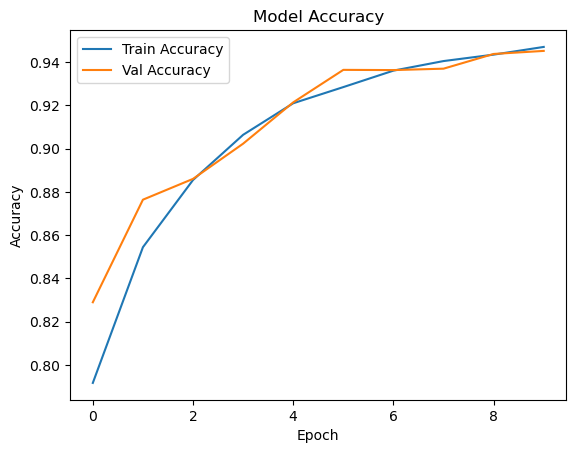

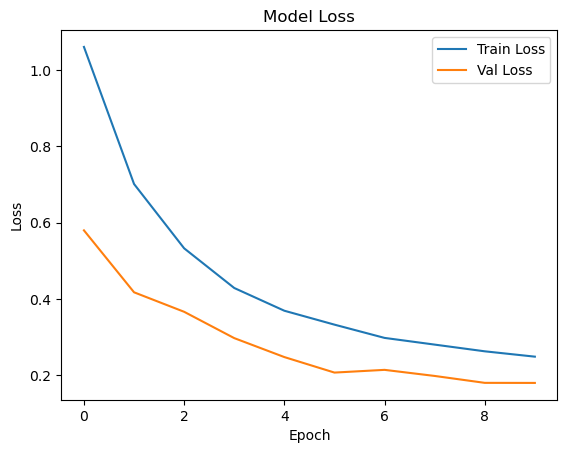

In [7]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

776/776 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step


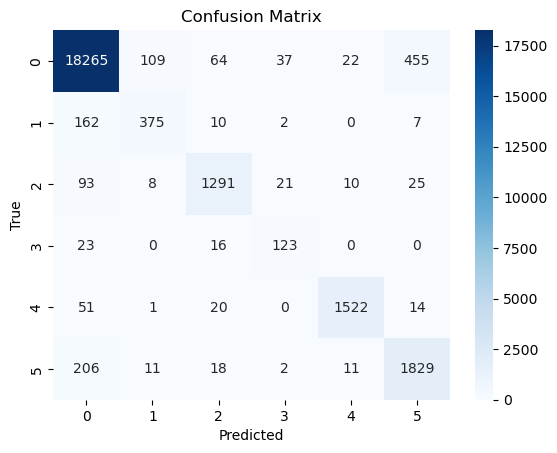

              precision    recall  f1-score   support

           0       0.97      0.96      0.97     18952
           1       0.74      0.67      0.71       556
           2       0.91      0.89      0.90      1448
           3       0.66      0.76      0.71       162
           4       0.97      0.95      0.96      1608
           5       0.78      0.88      0.83      2077

    accuracy                           0.94     24803
   macro avg       0.84      0.85      0.85     24803
weighted avg       0.95      0.94      0.94     24803



In [9]:
# Predict class probabilities
y_pred = model.predict(X_test)

# Convert probabilities to predicted classes
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert one-hot test labels to integer class labels
y_true_classes = np.argmax(y_test_cat, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification report
print(classification_report(y_true_classes, y_pred_classes))
